In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Nanndikonda Bharath\Downloads\ecommerce_dirty_dataset.csv")
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,NaN,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100495,79219,2023-10-02,2023-10-03,4301,Corporate,East,Odisha,Furniture,Chair,Chair Product 52,2667.00,1,0.00,829.68,185.0,Credit Card
100496,36298,2023-06-02,2023-06-05,4770,Consumer,North,Haryana,Furniture,Table,Table Product 2,56026.25,5,0.05,8928.97,217.0,Credit Card
100497,80041,2023-03-28,2023-04-02,3689,Consumer,East,Bihar,Furniture,Chair,Chair Product 55,22953.00,5,0.30,6327.46,95.0,Debit Card
100498,15667,2023-07-18,2023-07-20,1380,Corporate,West,Gujarat,Electronics,Laptop,Laptop Product 172,289241.75,5,0.05,106184.34,462.0,Credit Card


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100500 entries, 0 to 100499
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order_ID          100500 non-null  int64  
 1   Order_Date        100500 non-null  object 
 2   Ship_Date         100500 non-null  object 
 3   Customer_ID       100500 non-null  int64  
 4   Customer_Segment  97481 non-null   object 
 5   Region            100500 non-null  object 
 6   State             100500 non-null  object 
 7   Product_Category  100500 non-null  object 
 8   Sub_Category      100500 non-null  object 
 9   Product_Name      100500 non-null  object 
 10  Sales             100500 non-null  float64
 11  Quantity          100500 non-null  int64  
 12  Discount          100500 non-null  float64
 13  Profit            97481 non-null   float64
 14  Shipping_Cost     97494 non-null   float64
 15  Payment_Mode      100500 non-null  object 
dtypes: float64(4), int64

In [4]:
df.shape

(100500, 16)

In [5]:
df.columns

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Customer_ID',
       'Customer_Segment', 'Region', 'State', 'Product_Category',
       'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping_Cost', 'Payment_Mode'],
      dtype='object')

In [6]:
df.describe()

,Order_ID,Customer_ID,Sales,Quantity,Discount,Profit,Shipping_Cost
count,100500.000000,100500.000000,100500.000000,100500.000000,100500.000000,97481.000000,97494.000000
mean,49999.962398,3000.451443,51349.417056,2.997791,0.120175,13116.491054,285.374228
std,28867.058626,1153.093852,68902.019860,1.415007,0.113471,21735.774788,337.286266
min,1.000000,1000.000000,-5000.000000,1.000000,0.000000,36.040000,50.000000
25%,25005.750000,2004.000000,7832.475000,2.000000,0.050000,1763.200000,163.000000
50%,49985.500000,3000.000000,21265.000000,3.000000,0.100000,5101.810000,276.000000
75%,75014.250000,3997.000000,63424.812500,4.000000,0.200000,15577.510000,388.000000
max,100000.000000,4999.000000,399965.000000,5.000000,0.900000,500000.000000,10000.000000


In [7]:
df.isnull().sum()

Order_ID               0
Order_Date             0
Ship_Date              0
Customer_ID            0
Customer_Segment    3019
Region                 0
State                  0
Product_Category       0
Sub_Category           0
Product_Name           0
Sales                  0
Quantity               0
Discount               0
Profit              3019
Shipping_Cost       3006
Payment_Mode           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(481)

In [9]:
#handling the null values

In [10]:
df["Customer_Segment"]=df["Customer_Segment"].fillna(df["Customer_Segment"].mode()[0])

In [11]:
df["Profit"]=df["Profit"].fillna(df["Profit"].median())

In [12]:
df["Shipping_Cost"] = df["Shipping_Cost"].fillna(df["Shipping_Cost"].median())

In [13]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Ship_Date           0
Customer_ID         0
Customer_Segment    0
Region              0
State               0
Product_Category    0
Sub_Category        0
Product_Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping_Cost       0
Payment_Mode        0
dtype: int64

In [14]:
#Removing Duplicates

In [15]:
df = df.drop_duplicates().copy()

In [16]:
df.shape

(100019, 16)

In [17]:
#Correcting the data types

In [18]:
df["Order_Date"]= pd.to_datetime(df["Order_Date"])
df["Ship_Date"] =pd.to_datetime(df["Ship_Date"])

In [19]:
df["Sales"] =pd.to_numeric(df["Sales"],errors="coerce")
df["Profit"] =pd.to_numeric(df["Profit"], errors="coerce")

In [20]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Ship_Date           0
Customer_ID         0
Customer_Segment    0
Region              0
State               0
Product_Category    0
Sub_Category        0
Product_Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping_Cost       0
Payment_Mode        0
dtype: int64

In [21]:
#Logical Validation(eg: ship date is earlier than order)

In [22]:
df[df["Ship_Date"] < df["Order_Date"]]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
58,59,2022-04-02,2022-03-31,2571,Corporate,West,Rajasthan,Furniture,Chair,Chair Product 187,33548.80,4,0.20,5101.81,336.0,Debit Card
387,388,2023-05-21,2023-05-19,1735,Home Office,East,Bihar,Electronics,Laptop,Laptop Product 130,173593.50,5,0.05,60824.90,440.0,Debit Card
657,658,2022-04-27,2022-04-25,4586,Home Office,South,Tamil Nadu,Electronics,Accessories,Accessories Product 62,93864.75,3,0.05,17035.33,313.0,UPI
732,733,2023-11-20,2023-11-18,2464,Corporate,East,West Bengal,Clothing,Men,Men Product 76,15990.20,4,0.15,4520.68,327.0,Credit Card
1587,1588,2022-08-12,2022-08-10,2328,Corporate,West,Maharashtra,Electronics,Mobile,Mobile Product 125,189434.40,4,0.15,26407.61,221.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99963,99964,2022-10-02,2022-09-30,1478,Consumer,South,Karnataka,Furniture,Table,Table Product 169,25411.20,3,0.20,8290.54,248.0,Cash on Delivery
100068,17251,2022-03-02,2022-02-28,2209,Home Office,North,Haryana,Clothing,Kids,Kids Product 8,3717.00,2,0.10,1079.06,371.0,Debit Card
100250,16460,2023-02-28,2023-02-26,4563,Consumer,East,West Bengal,Furniture,Sofa,Sofa Product 53,7024.50,1,0.10,1947.89,418.0,Debit Card
100285,24425,2022-06-12,2022-06-10,4611,Consumer,West,Rajasthan,Furniture,Sofa,Sofa Product 131,9116.00,1,0.00,3340.11,276.0,Debit Card


In [23]:
mask = df["Ship_Date"]<df["Order_Date"]
df.loc[mask, "Ship_Date"] =df.loc[mask,"Order_Date"]

In [24]:
df[df["Ship_Date"] < df["Order_Date"]]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode


In [25]:
df[df["Sales"]<0]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
470,471,2022-07-23,2022-07-25,4375,Corporate,East,Odisha,Electronics,Accessories,Accessories Product 54,-5000.0,5,0.15,75466.83,428.0,UPI
1706,1707,2022-03-25,2022-03-26,1749,Consumer,East,West Bengal,Furniture,Chair,Chair Product 160,-5000.0,2,0.10,8349.24,58.0,UPI
3627,3628,2023-04-01,2023-04-06,1171,Home Office,North,Haryana,Electronics,Laptop,Laptop Product 182,-5000.0,5,0.05,51986.61,207.0,Cash on Delivery
4186,4187,2022-04-10,2022-04-17,4931,Consumer,West,Maharashtra,Clothing,Women,Women Product 177,-5000.0,2,0.00,2105.71,443.0,UPI
6067,6068,2023-03-18,2023-03-22,2880,Consumer,North,Haryana,Clothing,Men,Men Product 184,-5000.0,3,0.00,2326.83,239.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97644,97645,2023-10-08,2023-10-13,1794,Home Office,North,Punjab,Electronics,Accessories,Accessories Product 149,-5000.0,2,0.05,21369.92,250.0,Debit Card
98510,98511,2022-04-01,2022-04-05,3314,Consumer,North,Punjab,Clothing,Men,Men Product 164,-5000.0,4,0.05,4090.01,296.0,Credit Card
99372,99373,2022-01-30,2022-01-31,4328,Corporate,West,Gujarat,Clothing,Men,Men Product 65,-5000.0,5,0.00,1627.84,109.0,Debit Card
99757,99758,2022-09-26,2022-09-30,4199,Consumer,North,Haryana,Clothing,Women,Women Product 72,-5000.0,4,0.05,2350.66,130.0,Debit Card


In [26]:
df["Sales"] =df["Sales"].abs()

In [27]:
df[df["Ship_Date"] < df["Order_Date"]]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode


In [28]:
df[df["Discount"]>80]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode


In [29]:
Q1 = df["Shipping_Cost"].quantile(0.25)
Q3 = df["Shipping_Cost"].quantile(0.75)
IQR = Q3-Q1
upper = Q3 + 1.5*IQR
df[df["Shipping_Cost"]>upper]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
1426,1427,2023-01-26,2023-01-29,1623,Home Office,North,Punjab,Furniture,Sofa,Sofa Product 101,2813.00,1,0.00,912.15,10000.0,Debit Card
1499,1500,2023-10-27,2023-10-29,3506,Consumer,South,Telangana,Electronics,Laptop,Laptop Product 171,38187.80,1,0.30,9477.21,10000.0,Debit Card
1764,1765,2022-03-05,2022-03-10,3306,Corporate,South,Karnataka,Furniture,Table,Table Product 28,15566.40,4,0.10,4423.36,10000.0,UPI
2510,2511,2022-01-08,2022-01-11,1972,Consumer,West,Maharashtra,Electronics,Laptop,Laptop Product 154,139930.25,5,0.05,22472.26,10000.0,Cash on Delivery
2672,2673,2022-08-22,2022-08-25,4830,Consumer,East,Bihar,Clothing,Kids,Kids Product 134,8124.30,2,0.15,1113.57,10000.0,Cash on Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95299,95300,2023-06-14,2023-06-21,2866,Home Office,South,Karnataka,Electronics,Laptop,Laptop Product 40,98504.00,4,0.50,26546.85,10000.0,UPI
96342,96343,2022-02-19,2022-02-22,1708,Home Office,North,Delhi,Furniture,Chair,Chair Product 155,17619.00,3,0.00,3190.39,10000.0,UPI
97200,97201,2023-09-03,2023-09-06,1222,Corporate,South,Karnataka,Furniture,Sofa,Sofa Product 84,20281.00,2,0.15,4412.34,10000.0,Cash on Delivery
98696,98697,2022-10-10,2022-10-14,1283,Corporate,West,Maharashtra,Clothing,Women,Women Product 4,571.90,1,0.05,87.70,10000.0,Debit Card


In [30]:
df.loc[df["Shipping_Cost"]>upper,"Shipping_Cost"]=upper

In [31]:
#Standardization

In [32]:
df["Product_Category"] = df["Product_Category"].str.title().str.strip()

In [33]:
df.to_csv(r"C:\Users\Nanndikonda Bharath\OneDrive\Desktop\Cleaned.csv",index=False)


In [34]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Ship_Date           0
Customer_ID         0
Customer_Segment    0
Region              0
State               0
Product_Category    0
Sub_Category        0
Product_Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping_Cost       0
Payment_Mode        0
dtype: int64

In [35]:


#Phase 2
#Univariate 

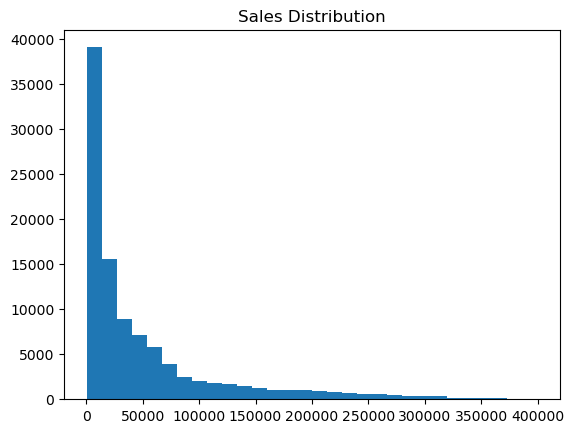

In [36]:
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.show()

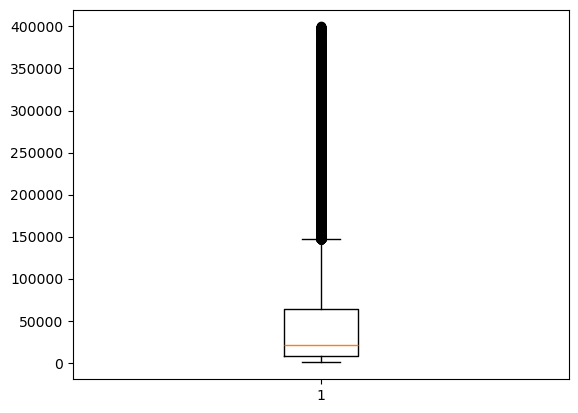

In [37]:
plt.boxplot(df["Sales"])
plt.show()
#Sales distribution using box plot

In [38]:
#Categorical

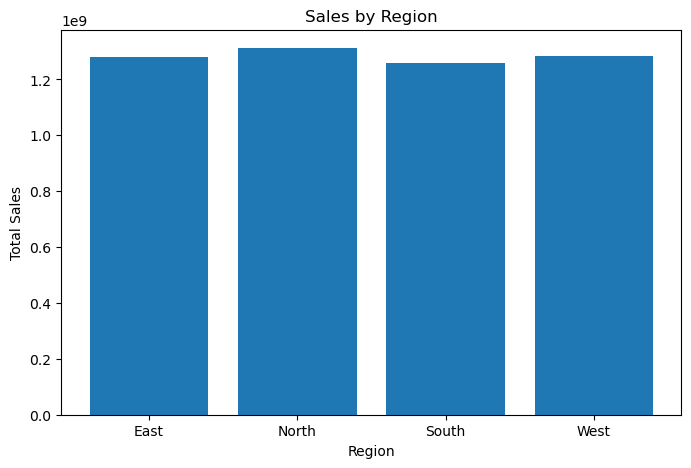

In [39]:
import matplotlib.pyplot as plt
sales_region = df.groupby("Region")["Sales"].sum()
plt.figure(figsize=(8,5))
plt.bar(sales_region.index, sales_region.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

<Axes: ylabel='Sales'>

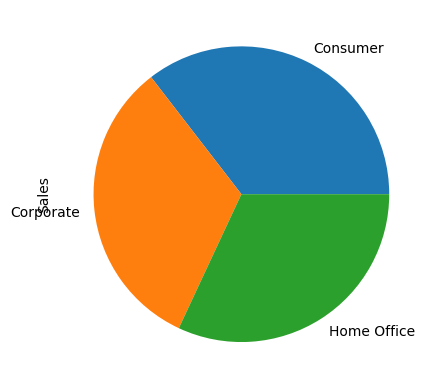

In [67]:
df.groupby("Customer_Segment")["Sales"].sum().plot(kind="pie")
#Segment wise Sales

<Axes: ylabel='Sales'>

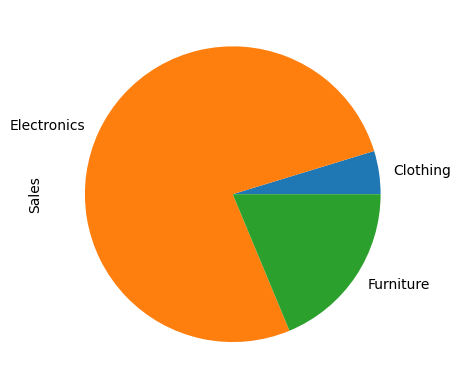

In [65]:
df.groupby("Product_Category")["Sales"].sum().plot(kind="pie")

<Axes: xlabel='Product_Name'>

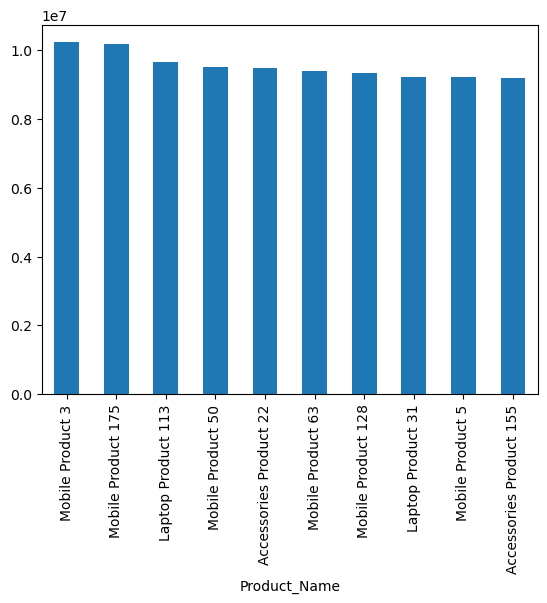

In [42]:
top=df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)
top.plot(kind="bar")
#Product wise Sales

<Axes: xlabel='State'>

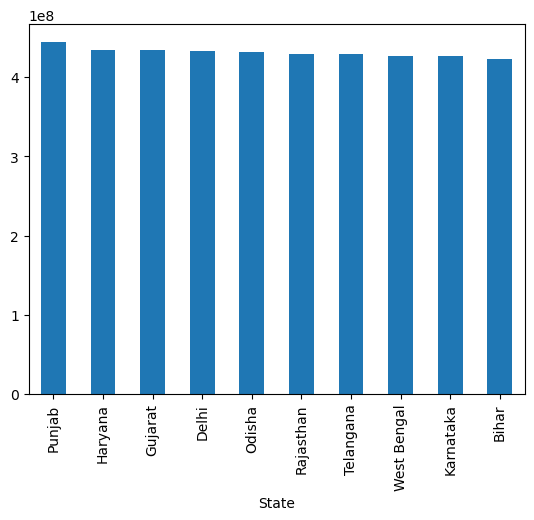

In [43]:
df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
#State wise Sales

In [44]:
#Bivariate


In [45]:
import matplotlib.pyplot as plt


Text(0, 0.5, 'Profit')

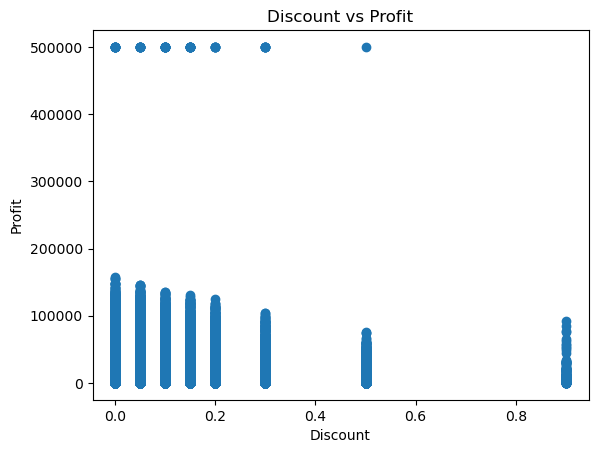

In [46]:
plt.scatter(df["Discount"],df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

Text(0, 0.5, 'Profit')

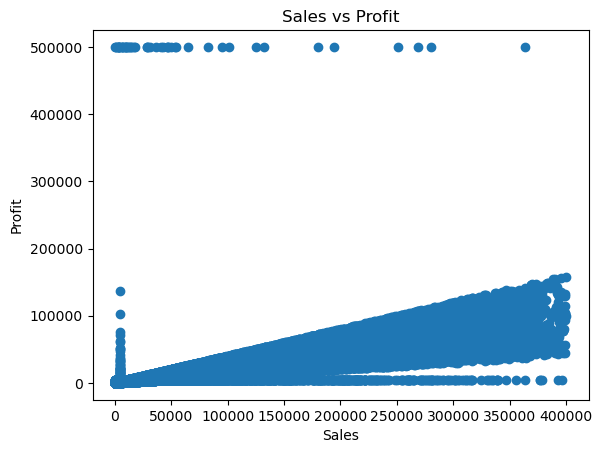

In [48]:
plt.scatter(df["Sales"],df["Profit"])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

In [49]:
df[["Discount","Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.066647
Profit,-0.066647,1.000000


Text(0.5, 1.0, 'Shipping cost vs profit')

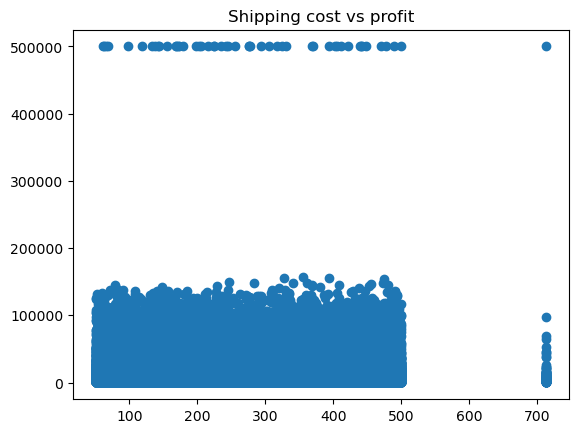

In [51]:
plt.scatter(df["Shipping_Cost"],df["Profit"])
plt.title("Shipping cost vs profit")

<Axes: ylabel='Profit'>

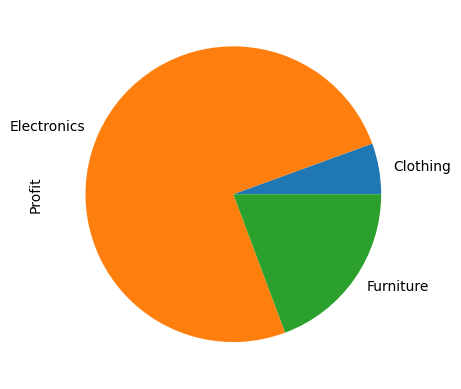

In [69]:
df.groupby("Product_Category")["Profit"].sum().plot(kind="pie")
#Category wise Profit

<Axes: ylabel='Profit'>

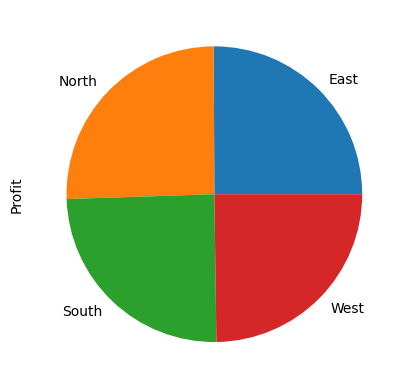

In [68]:
df.groupby("Region")["Profit"].sum().plot(kind="pie")
#Region wise profit

In [ ]:
#Date Analysis

In [54]:
df["Month"]=df["Order_Date"].dt.month_name()
df["Quarter"]=df["Order_Date"].dt.quarter

<Axes: xlabel='Month'>

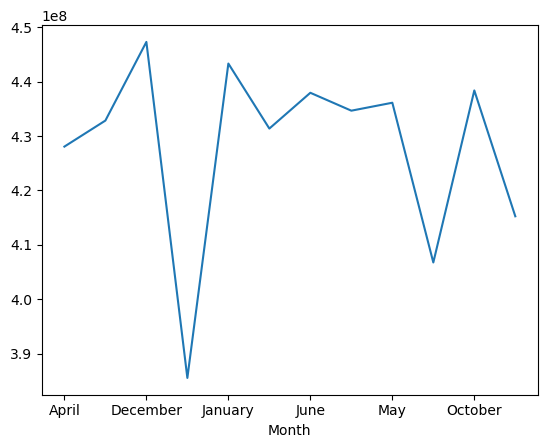

In [55]:
df.groupby("Month")["Sales"].sum().plot()
#month wise sales

<Axes: xlabel='Quarter'>

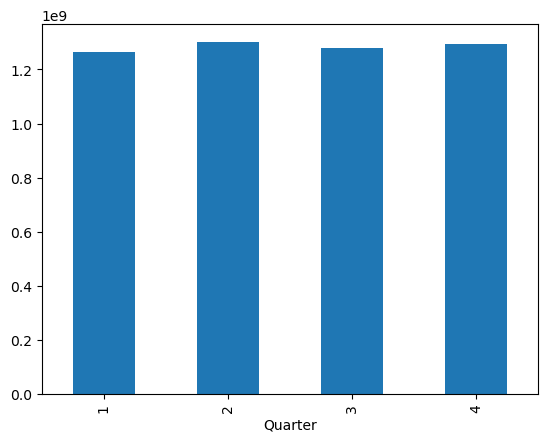

In [56]:
df.groupby("Quarter")["Sales"].sum().plot(kind="bar")
#quarter revenue

In [57]:
df.groupby("Month")["Sales"].sum().idxmax()
#Best Month

'December'

In [58]:
df.groupby("Month")["Sales"].sum().idxmin()
#Worst Month

'February'

In [ ]:
#Customer Analysis

In [59]:
customer=df.groupby("Customer_ID")["Sales"].sum().sort_values(ascending=False)
customer
#Customer wise Sales sum

Customer_ID
2768    3509375.20
2251    3221285.25
4379    3183041.90
1264    3116701.85
4870    2900345.05
           ...    
2280     251729.95
2491     243378.50
3408     240527.95
2762     233236.75
2386     206066.45
Name: Sales, Length: 4000, dtype: float64

In [60]:
df.groupby("Customer_Segment")["Sales"].mean()
#Segmet wise Sales

Customer_Segment
Consumer       51328.647866
Corporate      52087.813993
Home Office    50689.956904
Name: Sales, dtype: float64

In [61]:
df["Customer_ID"].value_counts()
#no. of orders

Customer_ID
1248    42
1513    42
2210    42
2058    42
2129    42
        ..
1086    11
4296    11
4843    11
2280    10
1563    10
Name: count, Length: 4000, dtype: int64

In [ ]:
#Correaltion matrix


<Axes: >

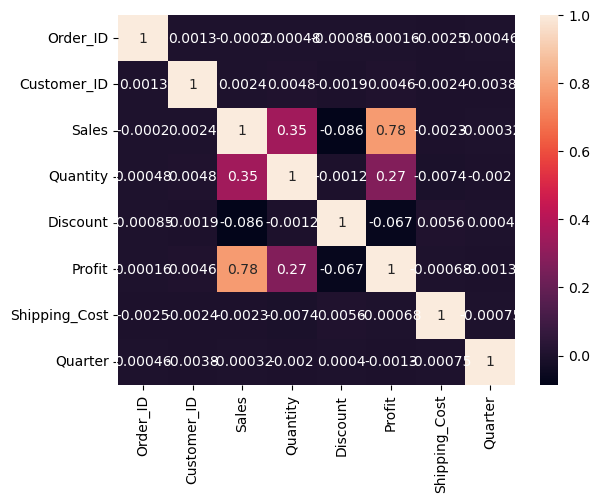

In [64]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
''' 1) Electronics accounts for an estimated ~77% of total sales — a concentration risk. A single bad quarter for that category 
     (supply issue, competitor pricing, demand shift) would sink overall revenue with no cushion from other categories. 
     Recommendation: set a category-diversification target (e.g., grow Furniture/Clothing to a combined 35% of sales within two quarters)
     and track it as a KPI, not just a one-time observation.
  2) Furniture and Clothing generate similar order volumes to Electronics but far less revenue. This points to a lower average order value or
     price point in those categories, not lower demand. Recommendation: test bundling or upselling within Furniture/Clothing orders to lift 
     average order value without needing new customers.
  3) Monthly sales are essentially flat — no seasonal or holiday spikes. For most retail categories this is unusual and suggests either untapped 
     seasonal demand or an absence of timed campaigns. Recommendation: run one deliberate seasonal promotion (e.g., a defined holiday window) and 
     compare lift against the flat baseline to test whether the flatness is a demand issue or a marketing gap.
  4) Regions and customer segments perform almost identically to one another. Uniform performance usually means pricing and promotions aren't 
     tailored locally. Recommendation: pilot one region-specific or segment-specific offer and measure whether it outperforms the uniform approach — 
     if it does, that's your business case for regional strategy. '''